# The projected density of states

Which atom, and which orbital, does a band belong to? The answer is the projection of every
Kohn-Sham state onto the pseudo-atomic orbitals the pseudopotential file already carries.
Summed against a delta function it gives the density of states resolved by atom, by $l$ and
by $m$; summed against the occupations it gives the **Löwdin charges**, which are one way of
saying how many electrons sit on an atom.

$$\rho_i(E) = \sum_{n\mathbf k} w_{\mathbf k}\,
   \big|\langle \tilde\phi_i | \hat S | \psi_{n\mathbf k}\rangle\big|^2\,
   \delta(E - \varepsilon_{n\mathbf k}),
\qquad
|\tilde\phi\rangle = O^{-1/2}\,|\phi\rangle,
\quad O_{ij} = \langle \phi_i | \hat S | \phi_j \rangle$$

$$\text{spilling} = 1 - \frac{1}{N_{\rm elec}} \sum_i \int^{E_F} \rho_i(E)\, dE$$

The projection carries the **overlap operator**, so on an ultrasoft dataset it is
$\langle\phi|S|\psi\rangle$ and not $\langle\phi|\psi\rangle$ -- which is what an amplitude
on an atom means once the norm has been given up inside the core.

Everything below is silicon with an ultrasoft dataset, against `projwfc.x` run on the same
input:

| | agreement |
|---|---|
| the projections themselves, band by band | **6.9e-4**, which is all its three decimals allow |
| the Löwdin charges | **4.6e-5** |
| the curves | 0.3% of their peak |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.io import comparison_table, read_pdos_file, read_projwfc_output
from pypresso.units import RY_TO_EV

CASES, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")

silicon = Calculator.from_file(CASES / "si2-us-dense.in", pseudo_dir=PSEUDO,
                               announce=False)

What gets projected is the *wavefunctions*, so the converged run itself is the input and
nothing is re-diagonalised; passing a denser `grid=` re-solves the bands on it first, exactly
as a non-self-consistent run would.

The energy window below is pinned to the reference file's, so that the two codes' curves are
sampled at the same energies. Left alone each sizes its own grid from its own band extremes,
which differ in the fourth decimal of an electronvolt.

In [2]:
grid_ev = read_pdos_file(CASES / "reference.si2-us-dense.pdos_tot")[0]
theirs = read_projwfc_output(CASES / "reference.projwfc.si2-us-dense")

pdos = silicon.get_pdos(delta_e=0.05 / RY_TO_EV,     # projwfc.x's DeltaE, which is in eV
                        degauss=0.0147,              # and its degauss, which is in Ry
                        emin=grid_ev[0] / RY_TO_EV, emax=grid_ev[-1] / RY_TO_EV)

print("%d atomic states, projectors %r, scheme %r"
      % (len(pdos.channels), pdos.projectors, pdos.scheme))
print(pdos.charges.format(tuple(silicon.system.structure.species[t].name
                                for t in silicon.system.structure.types)))

8 atomic states, projectors 'ortho-atomic', scheme 'gaussian'
Lowdin Charges:

     Atom #   1 (Si): total charge =   3.9647
       s =   1.1596
       p =   2.8051, pz=  0.9350, px=  0.9350, py=  0.9350
     Atom #   2 (Si): total charge =   3.9647
       s =   1.1596
       p =   2.8051, pz=  0.9350, px=  0.9350, py=  0.9350
     Spilling Parameter:   0.0088


## Against `projwfc.x`

The Löwdin charges side by side. `projwfc.x` prints four decimals, and that is the limit of
the comparison rather than the limit of the agreement.

In [3]:
rows = []
for atom, printed in theirs.charges.items():
    mine = pdos.charges.charges[atom - 1]
    rows.append(("Si %d total" % atom, pdos.charges.total[atom - 1], printed["total"]))
    for l, letter in enumerate("spd"[: mine.size]):
        if letter in printed:
            rows.append(("Si %d  %s" % (atom, letter), mine[l], printed[letter]))
    for m, label in enumerate(("pz", "px", "py")):
        rows.append(("Si %d  %s" % (atom, label),
                     pdos.charges.charges_lm[atom - 1, 1, m], printed[label]))
rows.append(("spilling", pdos.charges.spilling, theirs.spilling))

print(comparison_table(rows, fmt="{:.4f}",
                       headers=("", "pypresso", "projwfc.x", "difference")))

            pypresso  projwfc.x  difference
Si 1 total    3.9647     3.9647     3.7e-05
Si 1  s       1.1596     1.1596     9.4e-06
Si 1  p       2.8051     2.8051     4.6e-05
Si 1  pz      0.9350     0.9350     1.8e-05
Si 1  px      0.9350     0.9350     1.8e-05
Si 1  py      0.9350     0.9350     1.8e-05
Si 2 total    3.9647     3.9647     3.7e-05
Si 2  s       1.1596     1.1596     9.4e-06
Si 2  p       2.8051     2.8051     4.6e-05
Si 2  pz      0.9350     0.9350     1.8e-05
Si 2  px      0.9350     0.9350     1.8e-05
Si 2  py      0.9350     0.9350     1.8e-05
spilling      0.0088     0.0088     3.4e-05


The orbitals are Löwdin-orthogonalised over **every** atomic orbital in the crystal, which is
what makes the weights add up to at most one per band, by Bessel's inequality. The deficit is
the **spilling parameter**: how much of the occupied subspace the atomic basis cannot describe
at all. Silicon's is 0.009, so the projected curves sum to the total density of states to
about a percent, by construction rather than by error. A large spilling is a warning that the
atomic language is a poor description of the bonding -- a physical statement about the
material, not a numerical problem.

## The picture

**Left**, the total density of states with the $s$ and $p$ channels underneath it, and
`projwfc.x`'s own curves dashed on top. **Right**, the same weights on the band structure,
each band drawn with a marker sized by how $s$-like or $p$-like it is, which is what fat
bands means.

In [4]:
from pypresso.projwfc import atomic_projections           # no facade route to fat bands
from pypresso.workflows.nscf import fixed_density_states   # ... nor to the states behind them
from pypresso.system.kpoints import KPoints

path = KPoints.band_path([(0.5, 0.5, 0.5), (0.0, 0.0, 0.0), (1.0, 0.0, 0.0)], [20, 20, 0],
                         silicon.system.cell, crystal=False)
calculation, _, levels, states = fixed_density_states(
    silicon.system, silicon.pseudos, silicon.scf_result.density, kpoints=path, nbnd=8)
weights = atomic_projections(calculation, states)[0]
fermi = silicon.scf_result.homo * RY_TO_EV

x = path.path_length

And the picture:

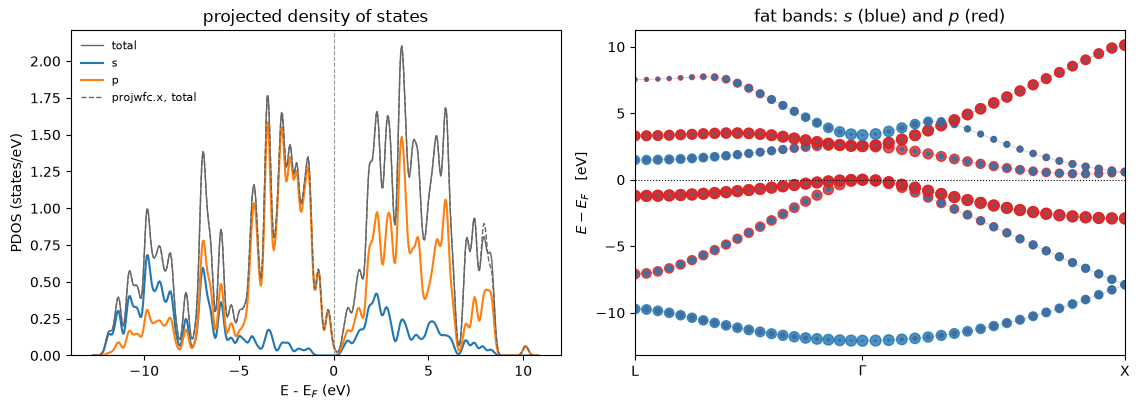

In [5]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11.5, 4.2))
pdos.plot(ax=left, by="l")
left.plot(grid_ev - fermi, read_pdos_file(CASES / "reference.si2-us-dense.pdos_tot")[1][0],
          "--", lw=1.0, color="0.4", label="projwfc.x, total")
left.legend(fontsize=8, frameon=False)
left.set_title("projected density of states")

for band in range(levels.shape[-1]):
    energy = levels[0, :, band] * RY_TO_EV - fermi
    for channel, colour in ((1, "C3"), (0, "C0")):
        share = weights[:, [c.index for c in pdos.channels if c.l == channel], band]
        right.scatter(x, energy, s=60 * share.sum(axis=1) + 1, color=colour, alpha=0.8)
    right.plot(x, energy, color="0.8", lw=0.6, zorder=0)
right.axhline(0.0, color="k", lw=0.8, ls=":")
right.set(xticks=[x[0], x[20], x[-1]], xticklabels=["L", r"$\Gamma$", "X"],
          xlim=(x[0], x[-1]), ylabel=r"$E - E_F$   [eV]",
          title="fat bands: $s$ (blue) and $p$ (red)")
fig.tight_layout()

The $s$ weight collapses onto the lowest valence band and the $p$ weight onto the upper
three, degenerate at $\Gamma$, which is the textbook picture of an $sp^3$ semiconductor read
**off** the projections rather than asserted about them.

The dashed curve lies on the solid one everywhere below about +8 eV. Above that they separate
for a reason that is not about the projection: the eighth band is the topmost one either code
computes, and neither eigensolver converges it, since both stop on the accuracy the *density*
needs. It is left in the picture rather than trimmed out of it, because that is what the two
codes actually produce.

## What it refuses

The weighted integration goes through the **same** density-of-states registry the total does,
so every scheme of notebook 06 is available here -- with one caveat inherited from QE rather
than added: `projwfc.x` silently runs the **linear** tetrahedron method whatever the
self-consistent run used, and this reproduces that only when asked to.

---
The tests behind this notebook: `tests/regression/test_pdos.py`, which holds the projections,
the Löwdin charges and the spilling against `projwfc.x` on seven cases; and
`tests/unit/test_projwfc.py`, which holds Bessel's inequality on the projections and the
orthogonalisation over the whole `natomwfc` manifold rather than the Hubbard one.